In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Example dataset
X = np.array([
    [2,3],
    [3,3],
    [2,1],
    [3,2],
    [7,8],
    [8,8],
    [7,6],
    [6,7]
])

y = np.array([-1,-1,-1,-1,1,1,1,1])


In [13]:


class SoftMarginSVM:
    
    def __init__(self, lr=0.001, C=1, n_iters=1000):
        self.lr = lr
        self.C = C
        self.n_iters = n_iters

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                
                if condition:
                    self.w -= self.lr * (2*self.w)
                else:
                    self.w -= self.lr * (2*self.w - self.C * y[idx] * x_i)
                    self.b -= self.lr * (-self.C * y[idx])

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)





### SVM Loss Function

$$
\text{Loss} = \frac{1}{2}\|w\|^{2} + C \sum_{i=1}^{n} \max \left(0,\; 1 - y_i (w^T x_i + b)\right)
$$

In [14]:
# Train model
model = SoftMarginSVM(C=1)
model.fit(X, y)

print("Weights:", model.w)
print("Bias:", model.b)

# Predictions
predictions = model.predict(X)
print("Predictions:", predictions)



Weights: [0.23626004 0.22375461]
Bias: -1.9069999999999008
Predictions: [-1. -1. -1. -1.  1.  1.  1.  1.]


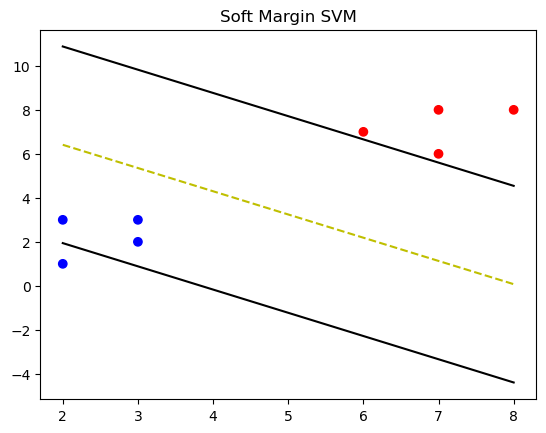

In [15]:
# Visualization
def plot_svm(X, y, model):

    def hyperplane(x, w, b, offset):
        return (-w[0]*x - b + offset) / w[1]

    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')

    x0_min = np.amin(X[:,0])
    x0_max = np.amax(X[:,0])

    x1_1 = hyperplane(x0_min, model.w, model.b, 0)
    x1_2 = hyperplane(x0_max, model.w, model.b, 0)

    x1_1_m = hyperplane(x0_min, model.w, model.b, -1)
    x1_2_m = hyperplane(x0_max, model.w, model.b, -1)

    x1_1_p = hyperplane(x0_min, model.w, model.b, 1)
    x1_2_p = hyperplane(x0_max, model.w, model.b, 1)

    plt.plot([x0_min,x0_max],[x1_1,x1_2],'y--')
    plt.plot([x0_min,x0_max],[x1_1_m,x1_2_m],'k')
    plt.plot([x0_min,x0_max],[x1_1_p,x1_2_p],'k')

    plt.title("Soft Margin SVM")
    plt.show()


plot_svm(X, y, model)